In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.preprocessing import LabelEncoder

In [57]:
print("="*70)
print("CUSTOMER PERSONALITY ANALYSIS USING MACHINE LEARNING")
print("="*70)

print("""
Objective:
The objective of this project is to analyze customer data,
understand purchasing behaviour and build a machine learning
model to predict whether a customer will respond to the
latest marketing campaign.
""")

CUSTOMER PERSONALITY ANALYSIS USING MACHINE LEARNING

Objective:
The objective of this project is to analyze customer data,
understand purchasing behaviour and build a machine learning
model to predict whether a customer will respond to the
latest marketing campaign.



In [58]:
df = pd.read_csv("marketing_campaign.csv",sep="\t")

print("\nDataset loaded successfully.")


Dataset loaded successfully.


In [59]:
print("="*70)
print("FIRST FIVE RECORDS")
print("="*70)

display(df.head())

FIRST FIVE RECORDS


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [60]:
print("="*70)
print("LAST FIVE RECORDS")
print("="*70)

display(df.tail())

LAST FIVE RECORDS


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [61]:
rows, columns = df.shape

print("="*70)
print("DATASET SHAPE")
print("="*70)

print(f"Total Rows : {rows}")
print(f"Total Columns : {columns}")

DATASET SHAPE
Total Rows : 2240
Total Columns : 29


In [62]:
print("="*70)
print("COLUMN NAMES")
print("="*70)

for col in df.columns:
    print(col)

COLUMN NAMES
ID
Year_Birth
Education
Marital_Status
Income
Kidhome
Teenhome
Dt_Customer
Recency
MntWines
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth
AcceptedCmp3
AcceptedCmp4
AcceptedCmp5
AcceptedCmp1
AcceptedCmp2
Complain
Z_CostContact
Z_Revenue
Response


In [63]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases 

In [64]:
print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)

display(df.describe(include="all"))

STATISTICAL SUMMARY


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31-08-2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [65]:
print("="*70)
print("MISSING VALUES")
print("="*70)

print(df.isnull().sum())

MISSING VALUES
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [66]:
print("="*70)
print("DUPLICATE RECORDS")
print("="*70)

print(df.duplicated().sum())

DUPLICATE RECORDS
0


In [67]:
print("="*70)
print("DATASET DETAILS")
print("="*70)

print(f"Total Customers : {len(df)}")
print(f"Total Features  : {len(df.columns)}")
print("Target Column   : Response")

DATASET DETAILS
Total Customers : 2240
Total Features  : 29
Target Column   : Response


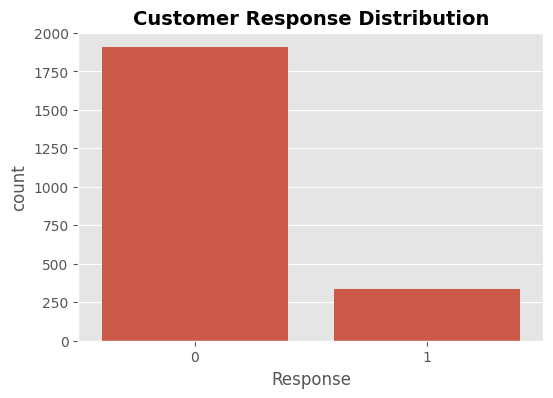

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Response"
)

plt.title("Customer Response Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

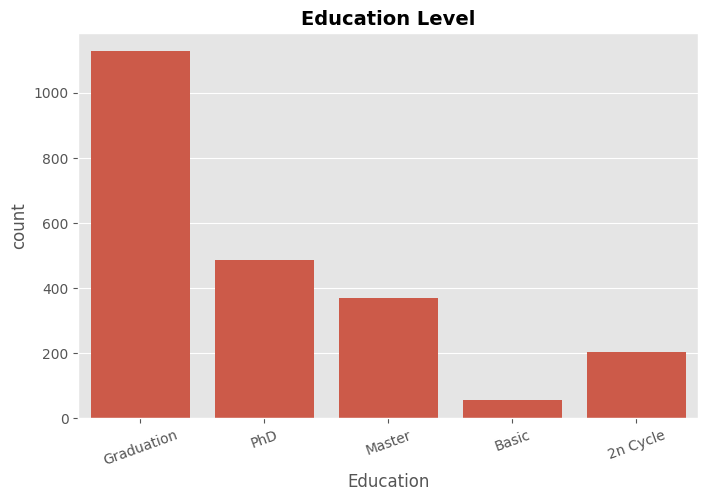

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education"
)

plt.title("Education Level",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

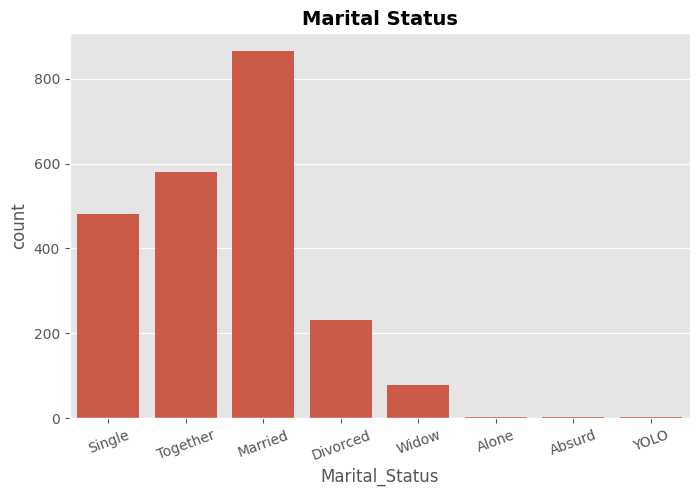

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Marital_Status"
)

plt.title("Marital Status",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

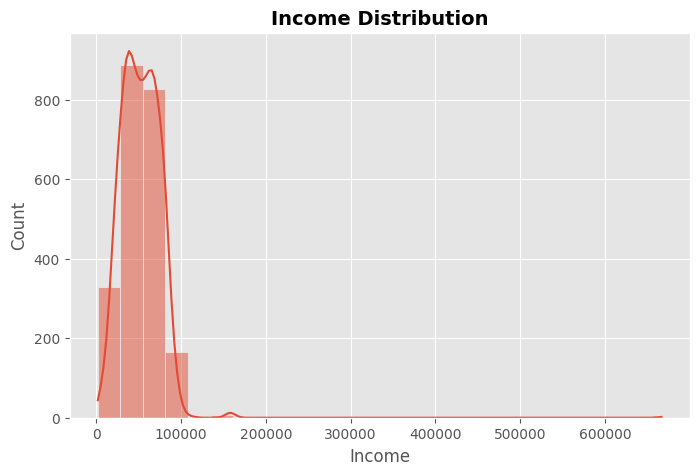

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Income"],
    bins=25,
    kde=True
)

plt.title("Income Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

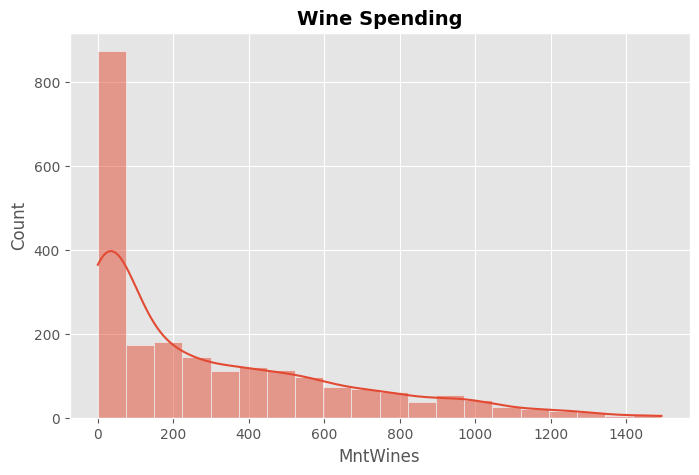

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MntWines"],
    bins=20,
    kde=True
)

plt.title("Wine Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

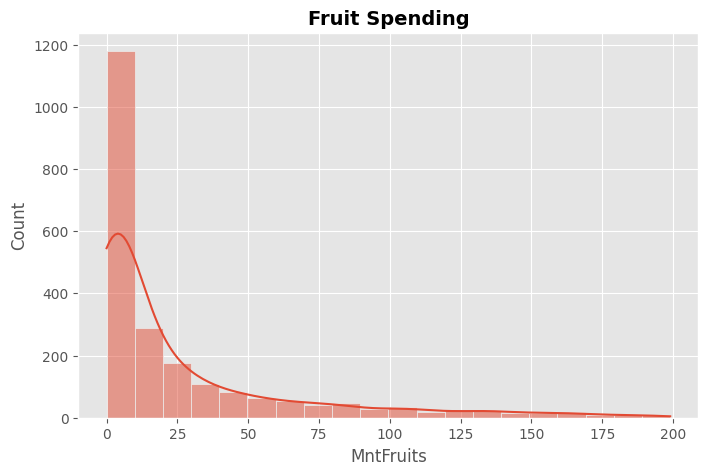

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MntFruits"],
    bins=20,
    kde=True
)

plt.title("Fruit Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

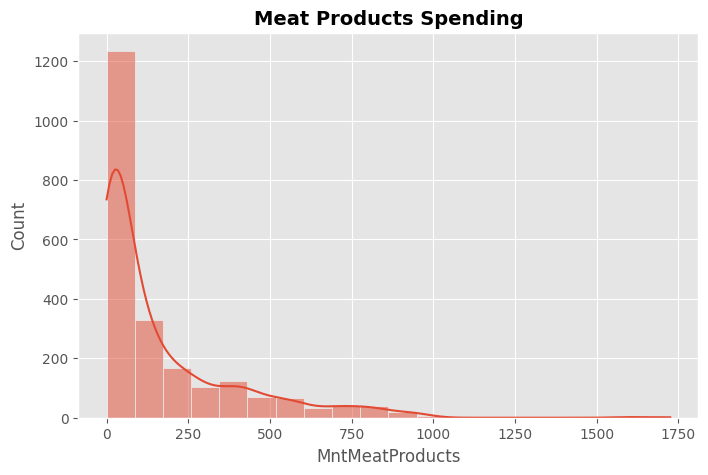

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MntMeatProducts"],
    bins=20,
    kde=True
)

plt.title("Meat Products Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

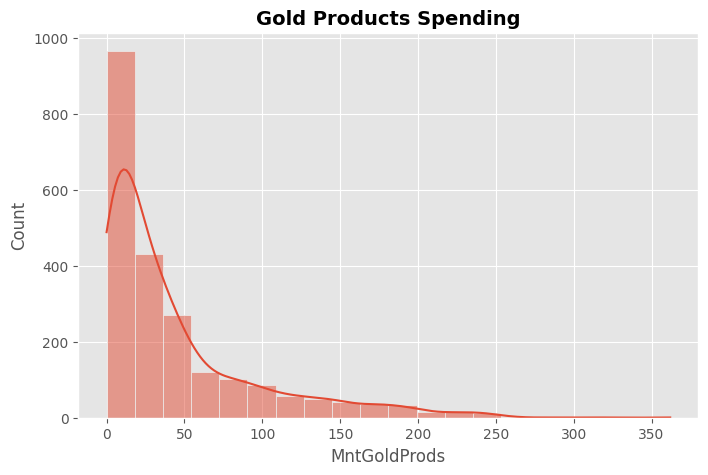

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MntGoldProds"],
    bins=20,
    kde=True
)

plt.title("Gold Products Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

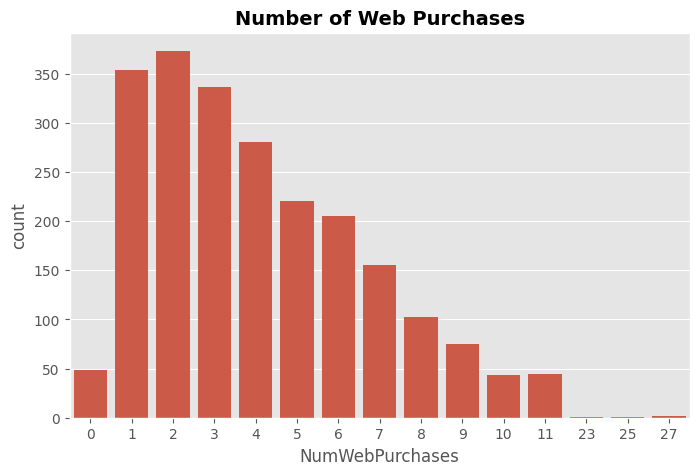

In [76]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumWebPurchases"
)

plt.title("Number of Web Purchases",
          fontsize=14,
          fontweight="bold")

plt.show()

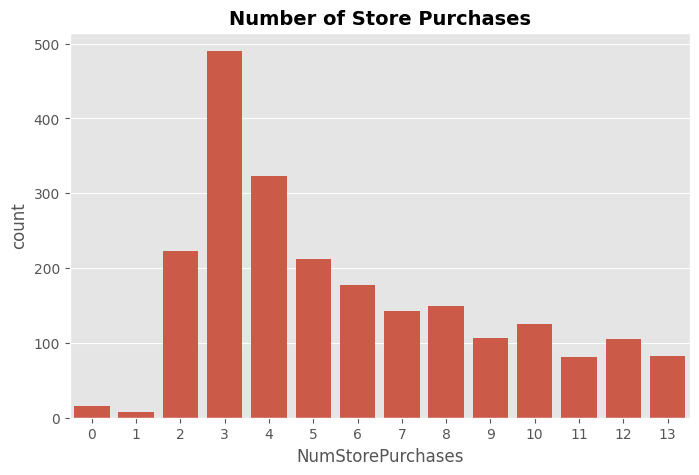

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumStorePurchases"
)

plt.title("Number of Store Purchases",
          fontsize=14,
          fontweight="bold")

plt.show()

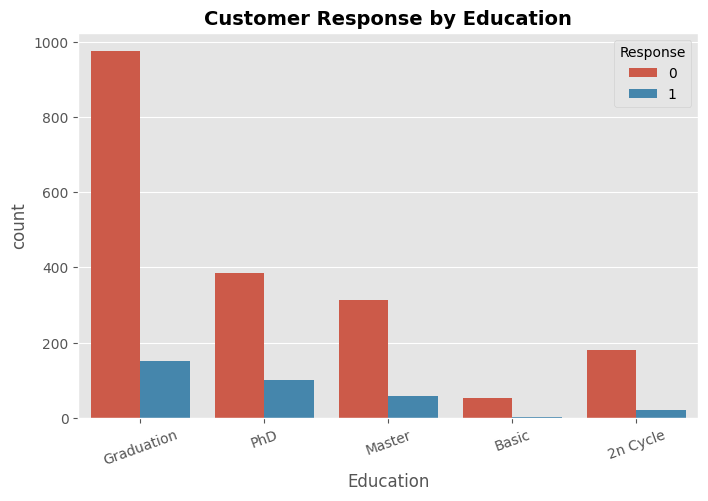

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Response"
)

plt.title("Customer Response by Education",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

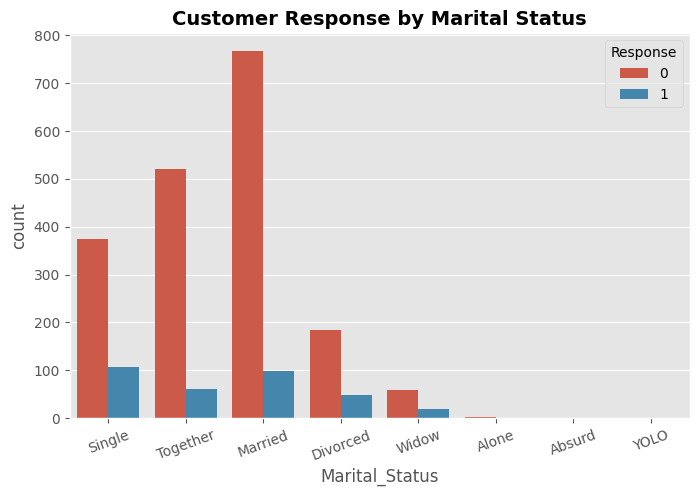

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Marital_Status",
    hue="Response"
)

plt.title("Customer Response by Marital Status",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

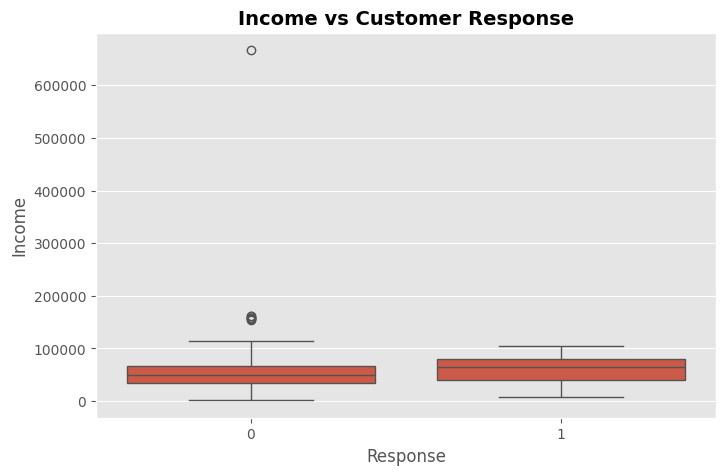

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Response",
    y="Income"
)

plt.title("Income vs Customer Response",
          fontsize=14,
          fontweight="bold")

plt.show()

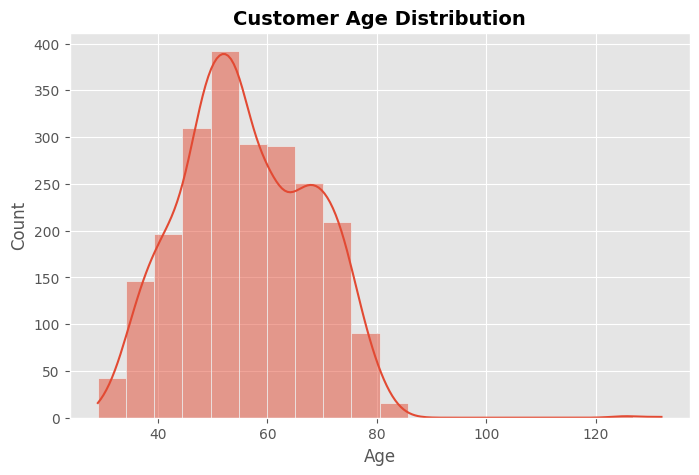

In [81]:
current_year = 2025

df["Age"] = current_year - df["Year_Birth"]

plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

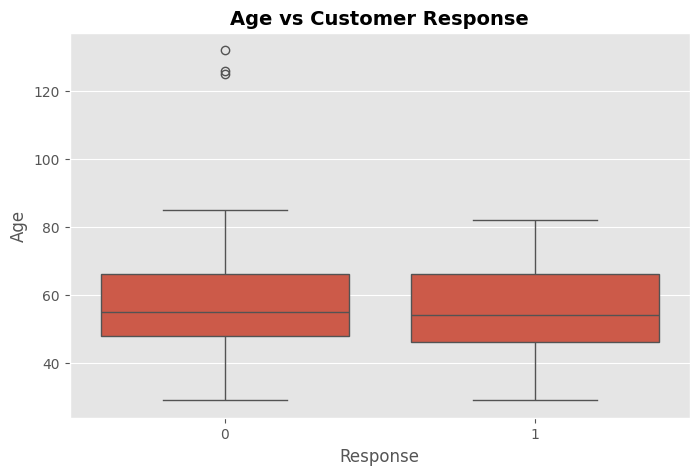

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Response",
    y="Age"
)

plt.title("Age vs Customer Response",
          fontsize=14,
          fontweight="bold")

plt.show()

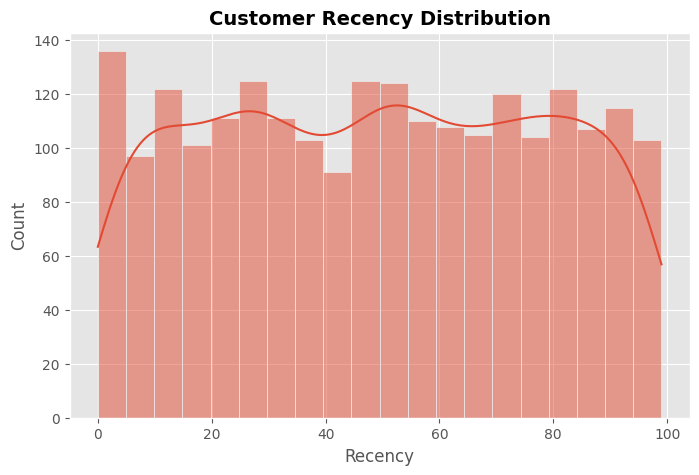

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Recency"],
    bins=20,
    kde=True
)

plt.title("Customer Recency Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

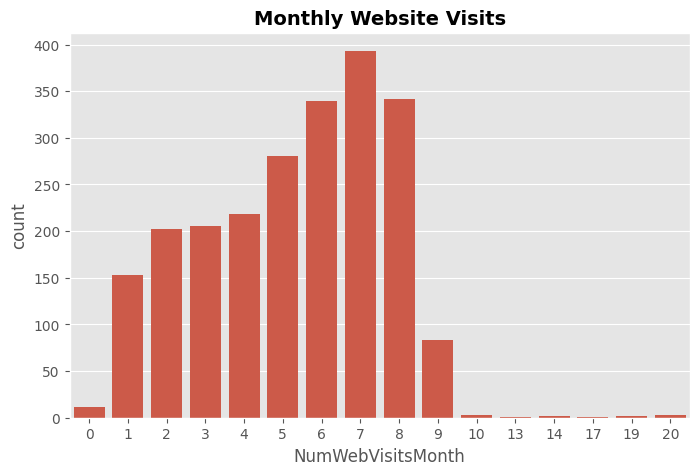

In [84]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumWebVisitsMonth"
)

plt.title("Monthly Website Visits",
          fontsize=14,
          fontweight="bold")

plt.show()

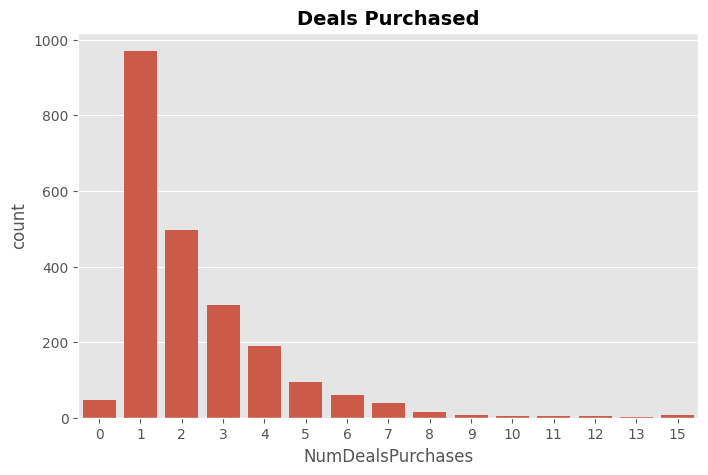

In [85]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumDealsPurchases"
)

plt.title("Deals Purchased",
          fontsize=14,
          fontweight="bold")

plt.show()

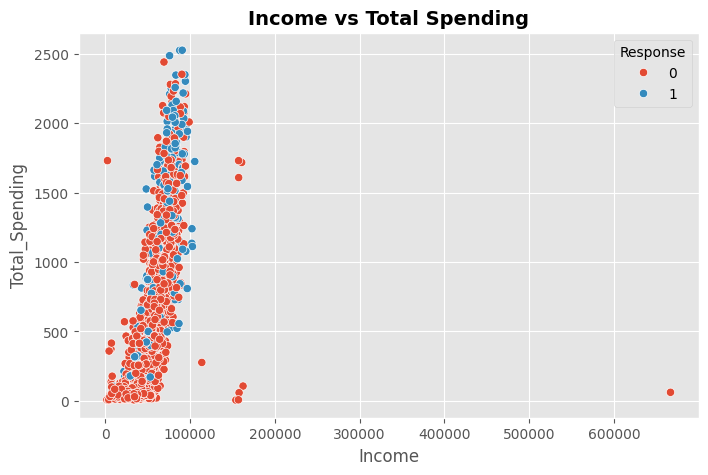

In [86]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Response"
)

plt.title("Income vs Total Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

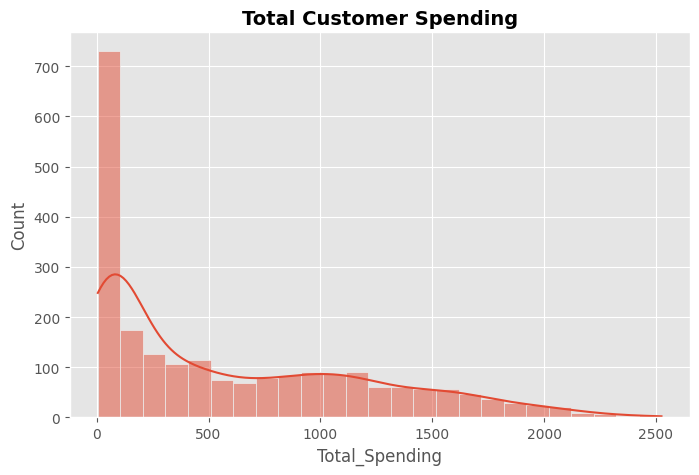

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Spending"],
    bins=25,
    kde=True
)

plt.title("Total Customer Spending",
          fontsize=14,
          fontweight="bold")

plt.show()

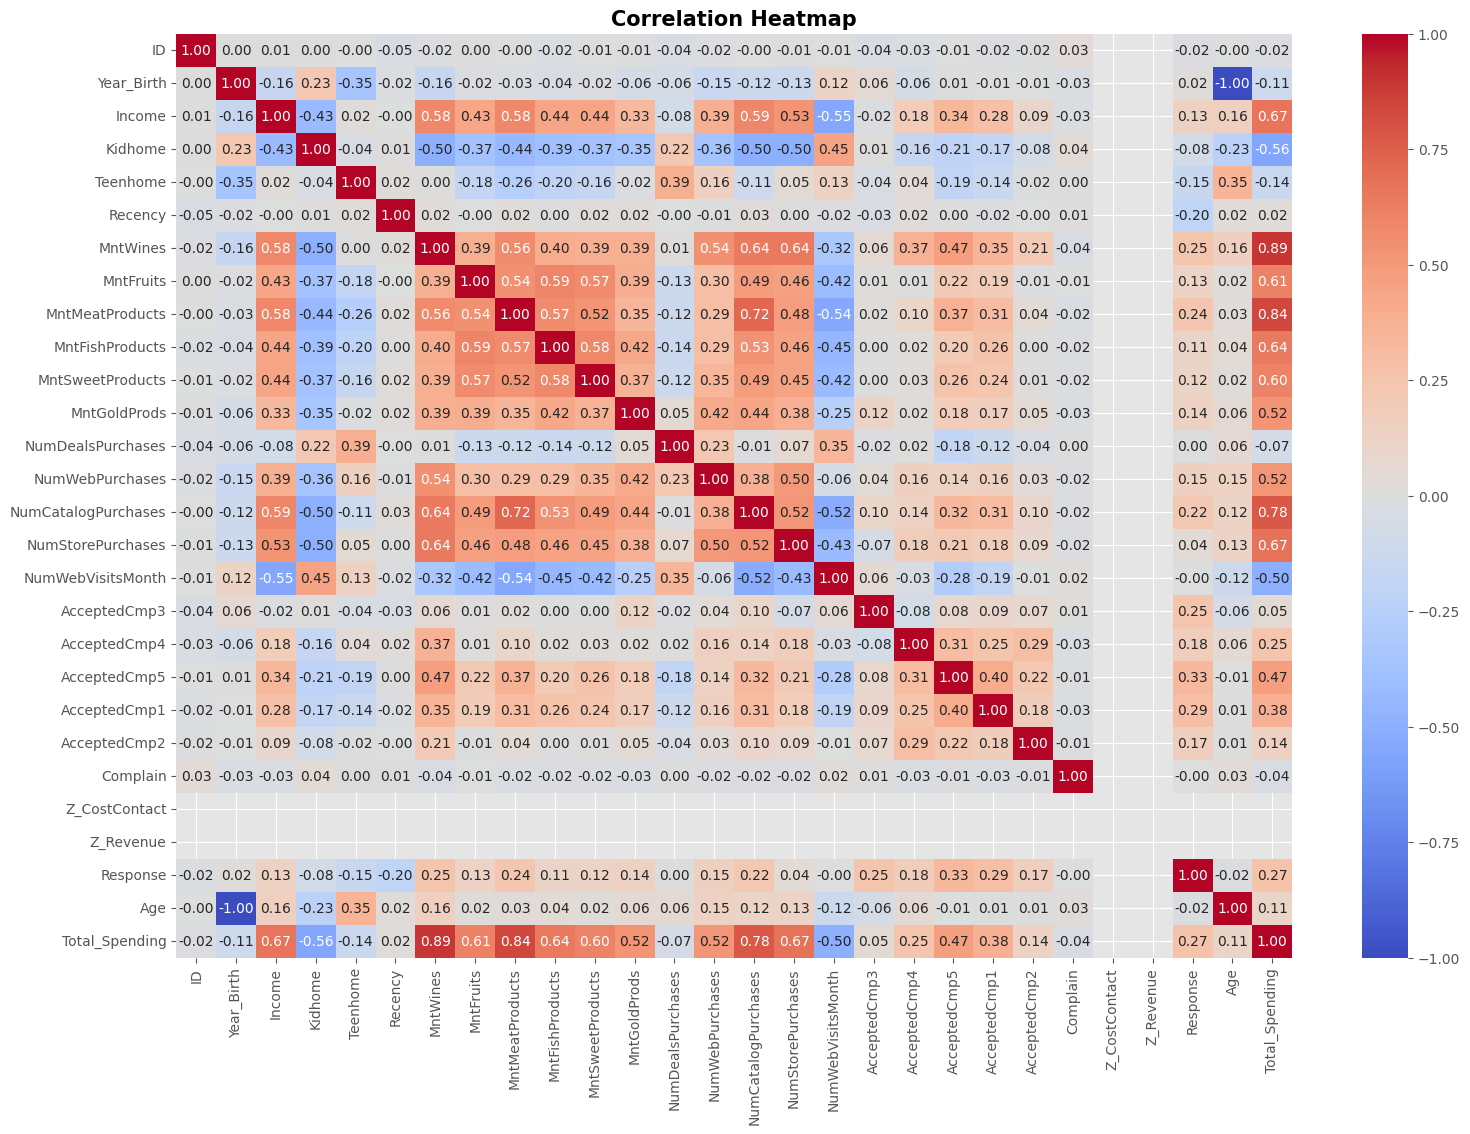

In [88]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap",
          fontsize=15,
          fontweight="bold")

plt.show()

In [89]:
response_percentage = (
    df["Response"]
    .value_counts(normalize=True)
    *100
)

print("="*70)
print("CUSTOMER RESPONSE PERCENTAGE")
print("="*70)

print(response_percentage)

CUSTOMER RESPONSE PERCENTAGE
Response
0    85.089286
1    14.910714
Name: proportion, dtype: float64


In [90]:
print("="*70)
print("DATASET INSIGHTS")
print("="*70)

print(f"Total Customers             : {len(df)}")

print(f"Average Age                : {round(df['Age'].mean(),2)}")

print(f"Average Income             : {round(df['Income'].mean(),2)}")

print(f"Average Spending           : {round(df['Total_Spending'].mean(),2)}")

print(f"Average Web Purchases      : {round(df['NumWebPurchases'].mean(),2)}")

print(f"Average Store Purchases    : {round(df['NumStorePurchases'].mean(),2)}")

DATASET INSIGHTS
Total Customers             : 2240
Average Age                : 56.19
Average Income             : 52247.25
Average Spending           : 605.8
Average Web Purchases      : 4.08
Average Store Purchases    : 5.79


In [91]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

df["Customer_Days"] = (
    pd.Timestamp.today() - df["Dt_Customer"]
).dt.days

df.drop("Dt_Customer", axis=1, inplace=True)

In [92]:
print("="*70)
print("MISSING VALUES BEFORE CLEANING")
print("="*70)

print(df.isnull().sum())

df["Income"] = df["Income"].fillna(df["Income"].median())

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

MISSING VALUES BEFORE CLEANING
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Total_Spending          0
Customer_Days           0
dtype: int64

Missing Values After Cleaning
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income             

In [93]:
encoder = LabelEncoder()

categorical_columns = [
    "Education",
    "Marital_Status"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("="*70)
print("CATEGORICAL COLUMNS ENCODED SUCCESSFULLY")
print("="*70)

CATEGORICAL COLUMNS ENCODED SUCCESSFULLY


In [94]:
X = df.drop("Response", axis=1)

y = df["Response"]

print("="*70)
print("FEATURES")
print("="*70)

display(X.head())

print("="*70)
print("TARGET")
print("="*70)

display(y.head())

FEATURES


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Age,Total_Spending,Customer_Days
0,5524,1957,2,4,58138.0,0,0,58,635,88,...,0,0,0,0,0,3,11,68,1617,5058
1,2174,1954,2,4,46344.0,1,1,38,11,1,...,0,0,0,0,0,3,11,71,27,4508
2,4141,1965,2,5,71613.0,0,0,26,426,49,...,0,0,0,0,0,3,11,60,776,4707
3,6182,1984,2,5,26646.0,1,0,26,11,4,...,0,0,0,0,0,3,11,41,53,4534
4,5324,1981,4,3,58293.0,1,0,94,173,43,...,0,0,0,0,0,3,11,44,422,4556


TARGET


,Response
0,1
1,0
2,0
3,0
4,0


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

TRAIN TEST SPLIT
Training Data : (1792, 30)
Testing Data  : (448, 30)


In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("="*70)
print("DATA SCALING COMPLETED")
print("="*70)

DATA SCALING COMPLETED


In [97]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print("="*70)
print("LOGISTIC REGRESSION MODEL CREATED")
print("="*70)

LOGISTIC REGRESSION MODEL CREATED


In [98]:
model.fit(X_train, y_train)

print("="*70)
print("MODEL TRAINED SUCCESSFULLY")
print("="*70)

MODEL TRAINED SUCCESSFULLY


In [99]:
y_pred = model.predict(X_test)

print("="*70)
print("PREDICTIONS GENERATED")
print("="*70)

PREDICTIONS GENERATED


In [100]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("="*70)
print("ACTUAL VS PREDICTED VALUES")
print("="*70)

display(comparison.head(10))

ACTUAL VS PREDICTED VALUES


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("="*70)
print("MODEL ACCURACY")
print("="*70)

print(f"Accuracy Score : {accuracy:.4f}")

print(f"Accuracy (%) : {accuracy*100:.2f}%")

MODEL ACCURACY
Accuracy Score : 0.8705
Accuracy (%) : 87.05%


In [102]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("="*70)
print("CONFUSION MATRIX")
print("="*70)

print(cm)

CONFUSION MATRIX
[[368  11]
 [ 47  22]]


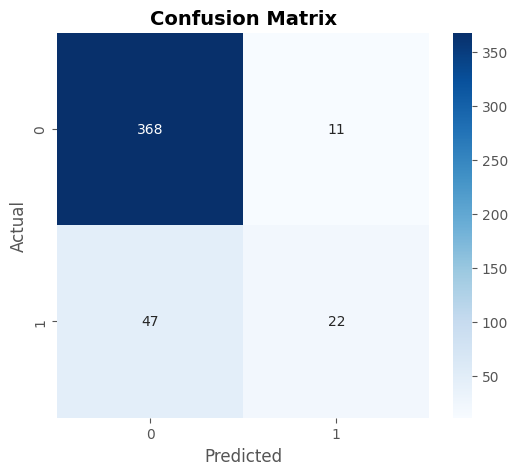

In [103]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [104]:
from sklearn.metrics import classification_report

print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.67      0.32      0.43        69

    accuracy                           0.87       448
   macro avg       0.78      0.64      0.68       448
weighted avg       0.85      0.87      0.85       448



In [105]:
from sklearn.metrics import (roc_auc_score,roc_curve)

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("="*70)
print("ROC AUC SCORE")
print("="*70)
print(f"ROC AUC Score : {auc:.4f}")

ROC AUC SCORE
ROC AUC Score : 0.8373


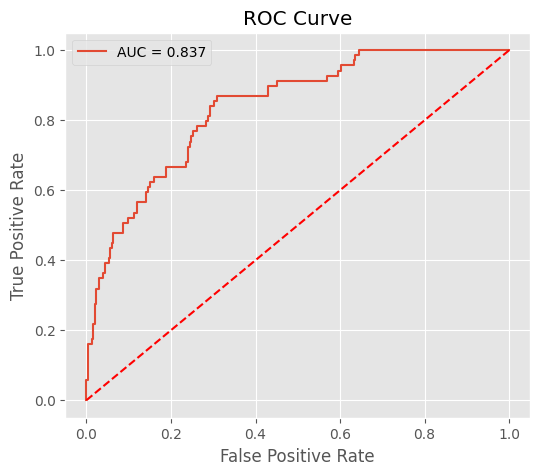

In [106]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [107]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*70)
print("TOP 10 IMPORTANT FEATURES")
print("="*70)

display(feature_importance.head(10))

TOP 10 IMPORTANT FEATURES


,Feature,Coefficient,Importance
7,Recency,-0.876802,0.876802
29,Customer_Days,0.782119,0.782119
19,AcceptedCmp3,0.556309,0.556309
2,Education,0.546446,0.546446
21,AcceptedCmp5,0.521007,0.521007
6,Teenhome,-0.512115,0.512115
22,AcceptedCmp1,0.399892,0.399892
17,NumStorePurchases,-0.382133,0.382133
10,MntMeatProducts,0.352214,0.352214
20,AcceptedCmp4,0.336979,0.336979


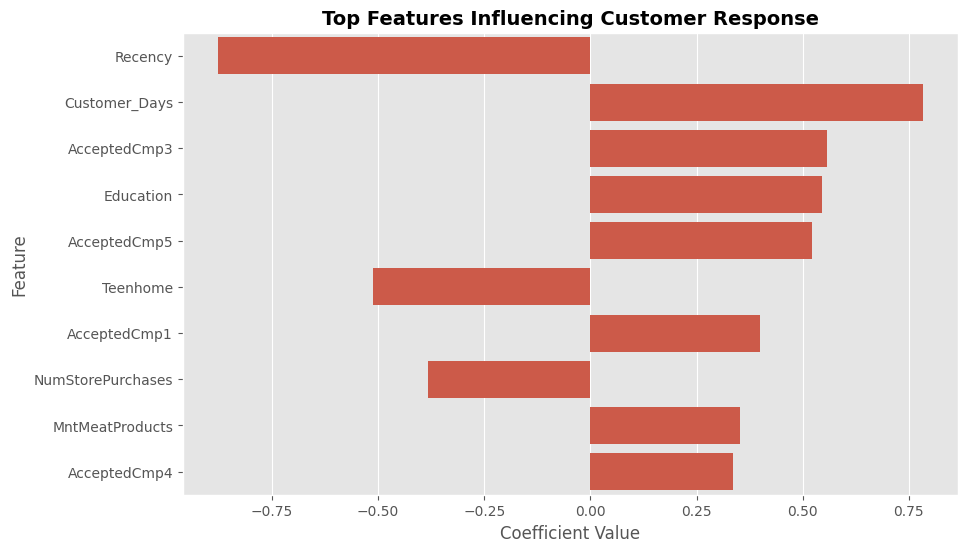

In [108]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Customer Response",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [109]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"Dataset Name        : Customer Personality Analysis")
print(f"Total Customers     : {len(df)}")
print(f"Total Features      : {len(df.columns)}")
print(f"Machine Learning    : Logistic Regression")
print(f"Target Variable     : Response")
print(f"Model Accuracy      : {accuracy*100:.2f}%")

PROJECT SUMMARY
Dataset Name        : Customer Personality Analysis
Total Customers     : 2240
Total Features      : 31
Machine Learning    : Logistic Regression
Target Variable     : Response
Model Accuracy      : 87.05%


In [110]:
print("="*70)
print("CONCLUSION")
print("="*70)

print("""
The Customer Personality Analysis dataset was analysed to understand
customer demographics, purchasing behaviour and campaign responses.

Exploratory Data Analysis helped identify important patterns related
to customer income, education, spending habits and purchasing activity.

After preprocessing the data, Logistic Regression was used to build
a classification model to predict whether a customer would respond
to the latest marketing campaign.

The model was evaluated using Accuracy Score, Confusion Matrix and
Classification Report.

The results show that customer response is influenced by several
factors such as income, spending behaviour, number of purchases,
recent activity and previous campaign interactions.

This analysis can help businesses identify potential customers,
improve marketing strategies and increase campaign success.
""")

CONCLUSION

The Customer Personality Analysis dataset was analysed to understand
customer demographics, purchasing behaviour and campaign responses.

Exploratory Data Analysis helped identify important patterns related
to customer income, education, spending habits and purchasing activity.

After preprocessing the data, Logistic Regression was used to build
a classification model to predict whether a customer would respond
to the latest marketing campaign.

The model was evaluated using Accuracy Score, Confusion Matrix and
Classification Report.

The results show that customer response is influenced by several
factors such as income, spending behaviour, number of purchases,
recent activity and previous campaign interactions.

This analysis can help businesses identify potential customers,
improve marketing strategies and increase campaign success.



In [111]:
print("="*70)
print("KEY INSIGHTS")
print("="*70)

print("""
• Customers with higher overall spending are more likely to respond
  to marketing campaigns.

• Income plays an important role in customer purchasing behaviour.

• Web purchases and store purchases provide useful information
  about customer preferences.

• Customer recency helps identify active and inactive customers.

• Previous campaign responses can help improve future marketing strategies.

• Machine Learning can assist businesses in targeting customers
  who are more likely to accept marketing offers.
""")

KEY INSIGHTS

• Customers with higher overall spending are more likely to respond
  to marketing campaigns.

• Income plays an important role in customer purchasing behaviour.

• Web purchases and store purchases provide useful information
  about customer preferences.

• Customer recency helps identify active and inactive customers.

• Previous campaign responses can help improve future marketing strategies.

• Machine Learning can assist businesses in targeting customers
  who are more likely to accept marketing offers.



In [112]:
print("="*70)
print("END OF PROJECT")
print("="*70)

print("""
Customer Personality Analysis using Machine Learning

Developed using:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!
""")

END OF PROJECT

Customer Personality Analysis using Machine Learning

Developed using:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!

